In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
# import nltk
# nltk.download('popular', quiet=True)
# import re
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer
# lemmatizer = WordNetLemmatizer()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [2]:
training_data = pd.read_csv("../data/router_training_data.csv")
training_data.head()

,question,label
0,How has unemployment changed since 2020?,analytics
1,Show GDP trends over the last decade.,analytics
2,Compare inflation and unemployment over time.,analytics
3,Is GDP related to employment levels?,analytics
4,Which years had the highest inflation?,analytics


In [3]:
# Create Feature and Label sets

# X = training_data['question']
# y = training_data['label']

X_train, X_test, y_train, y_test = train_test_split(
    training_data["question"],
    training_data["label"],
    test_size=0.2,
    random_state=42,
    stratify=training_data["label"]
)
print('Training Data :', X_train.shape)
print('Testing Data : ', X_test.shape)

# use the Bag of Words model (CountVectorizer) to convert the cleaned text into numeric features. This is needed for training the machine learning model.
# Train Bag of Words model
# Training Logistic Regression model
model = Pipeline([
    ("features", FeatureUnion([
        ("word", TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            lowercase=True
        )),
        ("char", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            lowercase=True
        )),
    ])),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        C=2.0
    ))
])

fit_logr_pipeline = model.fit(X_train, y_train)

Training Data : (261,)
Testing Data :  (66,)


In [4]:
# transform X_test using CV
# generate predictions
y_pred = fit_logr_pipeline.predict(X_test)

print(f"Logistic Regression model accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Classification Report: {classification_report(y_test, y_pred)}")

Logistic Regression model accuracy: 96.97%
Classification Report:               precision    recall  f1-score   support

   analytics       0.94      1.00      0.97        15
    greeting       1.00      0.92      0.96        12
    metadata       1.00      0.92      0.96        12
       other       0.96      1.00      0.98        27

    accuracy                           0.97        66
   macro avg       0.98      0.96      0.97        66
weighted avg       0.97      0.97      0.97        66



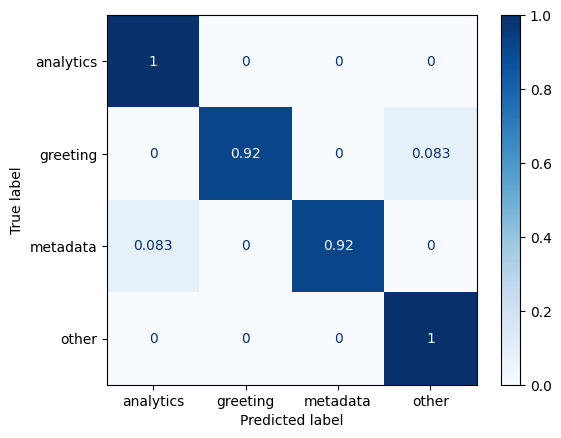

In [5]:
disp = ConfusionMatrixDisplay.from_estimator(
    fit_logr_pipeline,
    X_test,
    y_test,
    cmap=plt.cm.Blues,
    normalize="true",
)

plt.show()

In [6]:

# save model for later use
joblib.dump(fit_logr_pipeline, '../data/log_regression_route_classifier.joblib')

# inference
# Load from the saved file
loaded_model = joblib.load('../data/log_regression_route_classifier.joblib')
# Make a prediction
unseen_question=["years with the highest unemployment rate since 2000","hello world","what are all the different types of clouds","what is your favorite color?","what is FRED?"]
loaded_model.predict(unseen_question)

array(['analytics', 'greeting', 'other', 'other', 'metadata'],
      dtype=object)

In [8]:
loaded_model.predict(["what is unrate?"])

array(['metadata'], dtype=object)